<a href="https://colab.research.google.com/github/hsantos1985/neural_network/blob/main/OLIST_REDES_GENERATIVAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##OBJETIVO
---
O objetivo deste notebook é criar um modelo básico de rede generativa utilizando Transformers.
A rede irá prever as 5 próximas palavras que podem ser preenchidas
Para tanto, foi utilizada os dados da OLIST



In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

!pip install unidecode
from unidecode import unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 7.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#1- OBTENÇÃO DA BASE DE DADOS

In [ ]:
#OLIST ORDER REVIEWS
olist_principal= pd.read_csv('/content/drive/MyDrive/dataset_projeto/olist_order_reviews_dataset.csv')
olist_principal


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


#2-ANÁLISE PRELIMINAR E CRIAÇÃO DE COLUNAS DA BASE DE DADOS

In [ ]:
# Contar o número de pedidos únicos
qtd_olist_unico = olist_principal['order_id'].nunique()
# Imprimir o resultado usando f-strings
print(f'QTD pedidos únicos: {qtd_olist_unico}')

QTD pedidos únicos: 98673


In [ ]:
# Print do shape e contagem/porcentagem de 'review_score'
print("Shape of olist_principal:", olist_principal.shape)

# Obter categorias únicas em 'review_score' e ordenar
review_score_categories = sorted(olist_principal['review_score'].unique())

# Exibir a contagem e porcentagem de 'review_score' para cada valor único
print("\nAnálise por review_score:\n")
for review_score_category in review_score_categories:
    print(f"Para 'review_score' = {review_score_category}:")

    # Filtrar o DataFrame para a categoria específica de 'review_score'
    subset = olist_principal[olist_principal['review_score'] == review_score_category]

    # Calcular a contagem e porcentagem para a categoria atual
    count = len(subset)
    percentage = (count / len(olist_principal)) * 100

    # Exibir a contagem e porcentagem
    print(f"  Contagem: {count}")
    print(f"  Porcentagem: {percentage:.2f}%")

    print()  # Linha em branco para separar os grupos

Shape of olist_principal: (99224, 7)

Análise por review_score:

Para 'review_score' = 1:
  Contagem: 11424
  Porcentagem: 11.51%

Para 'review_score' = 2:
  Contagem: 3151
  Porcentagem: 3.18%

Para 'review_score' = 3:
  Contagem: 8179
  Porcentagem: 8.24%

Para 'review_score' = 4:
  Contagem: 19142
  Porcentagem: 19.29%

Para 'review_score' = 5:
  Contagem: 57328
  Porcentagem: 57.78%



In [ ]:
olist_principal.shape

(99224, 7)

In [ ]:
#retirada dos reiews diferentes de 3
olist_principal=(
olist_principal[olist_principal['review_score'] != 3].reset_index(drop=True)
)
olist_principal

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
91040,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
91041,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
91042,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
91043,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [ ]:
olist_principal['classe']=  np.where(
    olist_principal['review_score']>=4,'positivo','negativo'
)
olist_principal

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,classe
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,positivo
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13,positivo
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24,positivo
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,positivo
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,positivo
...,...,...,...,...,...,...,...,...
91040,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30,positivo
91041,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42,positivo
91042,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43,positivo
91043,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13,positivo


In [ ]:
olist_principal['review'] = np.where(
    olist_principal['review_comment_message'].isna(), 'sem review', 'com review'
)
olist_principal

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,classe,review
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,positivo,sem review
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13,positivo,sem review
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24,positivo,sem review
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,positivo,com review
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,positivo,com review
...,...,...,...,...,...,...,...,...,...
91040,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30,positivo,sem review
91041,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42,positivo,sem review
91042,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43,positivo,com review
91043,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13,positivo,sem review


In [ ]:
# Obter categorias únicas em 'review_comment_message'
review_categories = olist_principal['review'].unique()

# Exibir a contagem e porcentagem de 'classe' para cada categoria de 'review_comment_message'
for review_category in review_categories:
    print(f"Para '{review_category}':")

    # Filtrar o DataFrame para a categoria específica de 'review_comment_message'
    subset = olist_principal[olist_principal['review'] == review_category]

    # Calcular a contagem e porcentagem para 'classe'
    value_counts_classe = subset['classe'].value_counts()
    percentage_counts_classe = (value_counts_classe / len(subset)) * 100

    # Exibir a contagem e porcentagem
    for category in value_counts_classe.index:
        print(f" Classe: {category} - Contagem: {value_counts_classe[category]}, Porcentagem: {percentage_counts_classe[category]:.2f}%")



Para 'sem review':
 Classe: positivo - Contagem: 49940, Porcentagem: 93.13%
 Classe: negativo - Contagem: 3685, Porcentagem: 6.87%
Para 'com review':
 Classe: positivo - Contagem: 26530, Porcentagem: 70.90%
 Classe: negativo - Contagem: 10890, Porcentagem: 29.10%


In [ ]:
olist_principal = olist_principal[olist_principal['review_comment_message'].notna()].reset_index(drop=True)
olist_principal

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,classe,review
0,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,positivo,com review
1,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,positivo,com review
2,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47,positivo,com review
3,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16 00:00:00,2018-02-20 10:52:22,positivo,com review
4,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23 00:00:00,2018-05-24 03:00:01,positivo,com review
...,...,...,...,...,...,...,...,...,...
37415,5085bc489aa6b58a29c4f922d59ff826,18ed848509774f56cc8c1c0a1903ad7f,2,NaN,Tive um problema na entrega em que o correio c...,2018-02-21 00:00:00,2018-02-23 11:43:12,negativo,com review
37416,98fffa80dc9acbde7388bef1600f3b15,d398e9c82363c12527f71801bf0e6100,4,NaN,para este produto recebi de acordo com a compr...,2017-11-29 00:00:00,2017-11-30 15:52:51,positivo,com review
37417,df5fae90e85354241d5d64a8955b2b09,509b86c65fe4e2ad5b96408cfef9755e,5,NaN,Entregou dentro do prazo. O produto chegou em ...,2018-02-07 00:00:00,2018-02-19 19:47:23,positivo,com review
37418,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43,positivo,com review


In [ ]:
# Contar o número de pedidos únicos
qtd_olist_unico = olist_principal['order_id'].nunique()
# Imprimir o resultado usando f-strings
print(f'QTD pedidos únicos: {qtd_olist_unico}')

QTD pedidos únicos: 37299


#3-CRIAÇÃO DA ABT

In [ ]:
#CRIAÇÃO DA ABT
abt_int = olist_principal[['review_comment_message']]
abt_int

,review_comment_message
0,Recebi bem antes do prazo estipulado.
1,Parabéns lojas lannister adorei comprar pela I...
2,aparelho eficiente. no site a marca do aparelh...
3,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
4,"Vendedor confiável, produto ok e entrega antes..."
...,...
37415,Tive um problema na entrega em que o correio c...
37416,para este produto recebi de acordo com a compr...
37417,Entregou dentro do prazo. O produto chegou em ...
37418,"Excelente mochila, entrega super rápida. Super..."


In [ ]:
conteudo=olist_principal['review_comment_message'].tolist()

In [ ]:
conteudo

['Recebi bem antes do prazo estipulado.',
 'Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa',
 'aparelho eficiente. no site a marca do aparelho esta impresso como 3desinfector e ao chegar esta com outro nome...atualizar com a marca correta uma vez que é o mesmo aparelho',
 'Mas um pouco ,travando...pelo valor ta Boa.\r\n',
 'Vendedor confiável, produto ok e entrega antes do prazo.',
 'GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E ESSA COMPRA AGORA ME DECPCIONOU',
 'Péssimo',
 'Loja nota 10',
 'obrigado pela atençao amim dispensada',
 'A compra foi realizada facilmente.\r\nA entrega foi efetuada muito antes do prazo dado.\r\nO produto já começou a ser usado e até o presente,\r\nsem problemas.',
 'relógio muito bonito e barato.',
 'Não gostei ! Comprei gato por lebre',
 'Sempre compro pela Internet e a entrega ocorre antes do prazo combinado, que acredito ser o prazo máximo. No stark o prazo máximo já se esgotou e ainda não recebi o p

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Input, Model
from tensorflow.keras.layers import TextVectorization
import numpy as np
import pandas as pd

# Supondo que o dataframe `dados` já esteja carregado com uma coluna chamada 'text_pt'
# dados = pd.read_csv('caminho_para_seu_arquivo.csv')  # Se necessário carregar o DataFrame

# Parâmetros do modelo
sequence_length = 100
vocab_size = 5000
embed_dim = 128
latent_dim = 100
num_heads = 6

# Extrair os textos do DataFrame
texts = conteudo

# Configuração do TextVectorization
text_vectorization = TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length,
)

text_vectorization.adapt(texts)

import tensorflow as tf

# Definir função para separar treino e teste
def split_dataset(dataset, train_size=0.8):
    dataset_size = tf.data.experimental.cardinality(dataset).numpy()
    train_size = int(train_size * dataset_size)

    # Separar em treino e teste
    train_dataset = dataset.take(train_size)
    test_dataset = dataset.skip(train_size)

    return train_dataset, test_dataset

# Preparar dataset de linguagem modelada (LM)
def prepare_lm_dataset(text_batch):
    vectorized_sequences = text_vectorization(text_batch)
    x = vectorized_sequences[:, :-1]
    y = vectorized_sequences[:, 1:]
    return x, y

# Criar o dataset a partir dos textos
dataset = tf.data.Dataset.from_tensor_slices(texts)

# Aplicar preparação e dividir em treino e teste
lm_dataset = dataset.batch(256).map(prepare_lm_dataset, num_parallel_calls=tf.data.AUTOTUNE)

# Separar em treino e teste (80% treino e 20% teste)
train_dataset, test_dataset = split_dataset(lm_dataset)

In [ ]:
#Definição da camada de Positional Embedding
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(
            input_dim=input_dim, output_dim=output_dim)
        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length, output_dim=output_dim)
        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.output_dim = output_dim

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        mask = tf.keras.layers.Lambda(lambda x: tf.math.not_equal(x, 0))(inputs)
        return mask

    def get_config(self):
        config = super(PositionalEmbedding, self).get_config()
        config.update({
            "output_dim": self.output_dim,
            "sequence_length": self.sequence_length,
            "input_dim": self.input_dim,
        })
        return config

# Definição da camada TransformerDecoder
class TransformerDecoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention_1 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim)
        self.attention_2 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim)
        self.dense_proj = keras.Sequential(
            [layers.Dense(dense_dim, activation="relu"),
             layers.Dense(embed_dim),]
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.layernorm_3 = layers.LayerNormalization()
        self.supports_masking = True

    def get_config(self):
        config = super(TransformerDecoder, self).get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dense_dim": self.dense_dim,
        })
        return config

    def get_causal_attention_mask(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size, sequence_length = input_shape[0], input_shape[1]
        i = tf.range(sequence_length)[:, tf.newaxis]
        j = tf.range(sequence_length)
        mask = tf.cast(i >= j, dtype="int32")
        mask = tf.reshape(mask, (1, input_shape[1], input_shape[1]))
        mult = tf.concat(
            [tf.expand_dims(batch_size, -1),
             tf.constant([1, 1], dtype=tf.int32)], axis=0)
        return tf.tile(mask, mult)

    def call(self, inputs, encoder_outputs, mask=None):
        causal_mask = self.get_causal_attention_mask(inputs)
        if mask is not None:
            padding_mask = tf.cast(
                mask[:, tf.newaxis, :], dtype="int32")
            combined_mask = tf.minimum(padding_mask, causal_mask)
        else:
            combined_mask = causal_mask
            padding_mask = None  # Certifique-se de que padding_mask esteja definido
        attention_output_1 = self.attention_1(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=combined_mask)
        attention_output_1 = self.layernorm_1(inputs + attention_output_1)
        attention_output_2 = self.attention_2(
            query=attention_output_1,
            value=encoder_outputs,
            key=encoder_outputs,
            attention_mask=padding_mask,
        )
        attention_output_2 = self.layernorm_2(
            attention_output_1 + attention_output_2)
        proj_output = self.dense_proj(attention_output_2)
        return self.layernorm_3(attention_output_2 + proj_output)

In [ ]:
!pip install keras_nlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.2/572.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 78.8 MB/s eta 0:00:00


In [ ]:
# Construção do modelo
from keras_nlp.metrics import Perplexity
inputs = Input(shape=(None,), dtype="int64")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(inputs)
x = TransformerDecoder(embed_dim, latent_dim, num_heads)(x, x, mask=None)
outputs = layers.Dense(vocab_size, activation="softmax")(x)
model = Model(inputs, outputs)

# Compile o modelo
model.compile(loss="sparse_categorical_crossentropy", metrics=['accuracy', Perplexity()], optimizer='adam')

# Verifique a estrutura do modelo
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, None)           │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ positional_embedding_2    │ (None, None, 128)      │        652,800 │ input_layer_4[0][0]    │
│ (PositionalEmbedding)     │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ transformer_decoder_2     │ (None, None, 128)      │        817,892 │ positional_embedding_… │
│ (TransformerDecoder)      │                        │                │ positional_embedding_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, None, 5000)     │        645,000 │ transformer_decoder_2… │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,115,692 (8.07 MB)

 Trainable params: 2,115,692 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Treinamento do modelo
model.fit(train_dataset, epochs=10, validation_data=test_dataset)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:915: UserWarning: Layer 'query' (of type EinsumDense) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:915: UserWarning: Layer 'key' (of type EinsumDense) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:915: UserWarning: Layer 'value' (of type EinsumDense) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


117/117 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - accuracy: 0.7705 - loss: 6.3104 - perplexity: 2.0671 - val_accuracy: 0.8161 - val_loss: 4.1297 - val_perplexity: 1.5934
Epoch 2/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8140 - loss: 3.7218 - perplexity: 1.5318 - val_accuracy: 0.7677 - val_loss: 2.3944 - val_perplexity: 1.3104
Epoch 3/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7904 - loss: 2.0496 - perplexity: 1.2649 - val_accuracy: 0.9738 - val_loss: 1.3366 - val_perplexity: 1.1629
Epoch 4/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9772 - loss: 1.1175 - perplexity: 1.1367 - val_accuracy: 0.9839 - val_loss: 0.8342 - val_perplexity: 1.0987
Epoch 5/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9858 - loss: 0.6716 - perplexity: 1.0800 - val_accuracy: 0.9886 - val_loss: 0.5825 - val_perplexity: 1.0679
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9910 - loss: 0.4204 - perplexity: 1.0494 - val_accuracy: 0.9924 - va

In [ ]:
def generate_text(prompt, generate_length=10, temperature=3.0):
    sentence = prompt
    for _ in range(generate_length):
        # Vetoriza a frase atual
        tokenized_sentence = text_vectorization([sentence])

        # Faz previsões com o modelo
        predictions = model(tokenized_sentence)

        # Obtém o próximo token com base na temperatura
        next_token = sample_next(predictions[0, -1, :], temperature)
        # Converte o índice do token em palavra
        sampled_token = tokens_index[next_token]
        # Adiciona a palavra à frase
        sentence += " " + sampled_token
        # Verifica se a frase atingiu o tamanho máximo do modelo
        if len(sentence.split()) >= sequence_length:
            break
    return sentence

In [ ]:
# Função para amostrar o próximo token
def sample_next(predictions, temperature=1.0):
    predictions = np.asarray(predictions).astype("float64")
    predictions = np.log(predictions) / temperature
    exp_preds = np.exp(predictions)
    predictions = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, predictions, 1)
    # adicionar a funcionalidade aqui
    return np.argmax(probas)

In [ ]:
tokens_index = dict(enumerate(text_vectorization.get_vocabulary()))

In [ ]:
prompt = 'Entregou dentro do'

# Quanto maior for a temperatura, mais "criativo" o modelo será.

generated_sentence = generate_text(prompt, generate_length=10, temperature=10.0)
print("Generated text:", generated_sentence)

Generated text: Entregou dentro do devolvido soubesse enviado colocar restante  simplesmente tambem 220 instrução


In [ ]:
prompt = 'Entregou dentro do'

# Quanto maior for a temperatura, mais "criativo" o modelo será.

generated_sentence = generate_text(prompt, generate_length=15, temperature=20.0)
print("Generated text:", generated_sentence)

Generated text: Entregou dentro do feriado fornecer remold bom instalado ao palhaçada desse trÊs devolvi trocaram pareceu pintado 18 firmeza


##NUVEM DE PALAVRAS

In [ ]:
#tratando o texto
full_text = ' '.join(abt_int['review_comment_message'])

In [ ]:
# cria o objeto da figura da word cloud
from wordcloud import WordCloud
wc = WordCloud(background_color='black').generate(full_text)

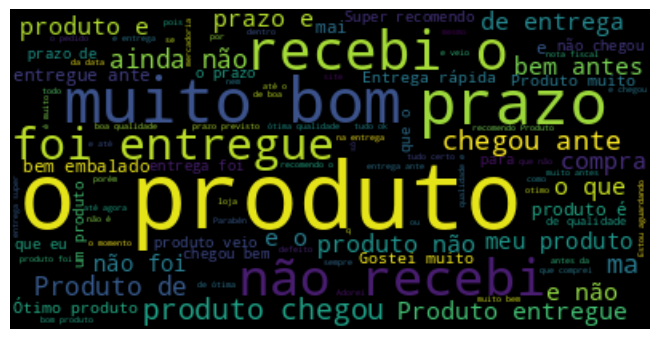

In [ ]:
# plota a word cloud geral
import matplotlib.pyplot as plt

plt.imshow(wc, interpolation='bilinear')
plt.grid('off')
plt.axis('off')
plt.tight_layout(pad=0)